### Importing required packages, reading data from various sources

In [ ]:
!pip install xgboost pysparkling

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.2/166.2 kB 9.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pysparkling: filename=pysparkling-0.6.2-py3-none-any.whl size=185872 sha256=e9bf641953c2dc80a98b505ebff6edc702c62a8ad3779eb64395bd19a84744fd
  Stored in directory: /root/.cache/pip/wheels/65/4e/9f/ebee95d389ea78f11338ba3fe358c09d047f065c4d6ac4cd88
Successfully built pysparkling


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lit, avg, count
from pyspark.ml.feature import VectorAssembler, StringIndexer, Imputer
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [ ]:
spark = SparkSession.builder.appName("BigDataAnalyticsDemo").getOrCreate()

split_1_path = "/content/split_1.csv"
split_2_path = "/content/split_2.csv"

df1 = spark.read.csv(split_1_path, header=True, inferSchema=True)
df2 = spark.read.csv(split_2_path, header=True, inferSchema=True)
print("File 1")
df1.show(5)
print("File 2")
df2.show(5)

File 1
+---------+-------------+---+-----------+----------+---------+-----------------+---------------+----------+-----------------------+---------------------------+-----------------------------------------+--------+--------+
|PatientID|         Name|Age|Cholesterol|Hemoglobin|Platelets|White Blood Cells|Red Blood Cells|Hematocrit|Mean Corpuscular Volume|Mean Corpuscular Hemoglobin|Mean Corpuscular Hemoglobin Concentration| Insulin|     BMI|
+---------+-------------+---+-----------+----------+---------+-----------------+---------------+----------+-----------------------+---------------------------+-----------------------------------------+--------+--------+
|   BM7374|Bobby JacksOn| 30|   0.033693|  0.114755| 0.997927|         0.562604|       0.866499|  0.578042|               0.914615|                   0.026864|                                 0.038641|0.645755|0.070888|
|   BM4624| LesLie TErRy| 62|   0.972653|  0.084998| 0.180909|         0.675736|       0.563889|  0.798382|      

### Data Transformation:

Joining operation

In [ ]:
joined_df = df1.join(df2, on="PatientID", how="inner")
print("Joined DF on key=\"PatientID\"")
joined_df.show(5)

Joined DF on key="PatientID"
+---------+-------------+---+-----------+----------+---------+-----------------+---------------+----------+-----------------------+---------------------------+-----------------------------------------+--------+--------+-----------------------+------------------------+-------------+--------+---------------+---------------+--------+--------+----------+----------+--------+------------------+--------+
|PatientID|         Name|Age|Cholesterol|Hemoglobin|Platelets|White Blood Cells|Red Blood Cells|Hematocrit|Mean Corpuscular Volume|Mean Corpuscular Hemoglobin|Mean Corpuscular Hemoglobin Concentration| Insulin|     BMI|Systolic Blood Pressure|Diastolic Blood Pressure|Triglycerides|   HbA1c|LDL Cholesterol|HDL Cholesterol|     ALT|     AST|Heart Rate|Creatinine|Troponin|C-reactive Protein| Disease|
+---------+-------------+---+-----------+----------+---------+-----------------+---------------+----------+-----------------------+---------------------------+----------

Dropping duplicates and filling missing values

In [ ]:
duplicates_count = joined_df.count() - joined_df.dropDuplicates().count()
joined_df = joined_df.dropDuplicates()

avg_age = joined_df.select(avg(col("Age").cast("float"))).first()[0]
missing_age_count = joined_df.filter(col("Age").isNull()).count()
joined_df = joined_df.fillna({"Age": avg_age})

print(f"Number of duplicates dropped: {duplicates_count}")
print(f"Number of missing ages filled: {missing_age_count}")

Number of duplicates dropped: 0
Number of missing ages filled: 18


Converting string columns to numerical values

In [ ]:
feature_columns = [column for column in joined_df.columns if column not in ["PatientID", "Name", "Age", "Disease"]]
for feature in feature_columns:
    if dict(joined_df.dtypes)[feature] == "string":
        joined_df = joined_df.withColumn(feature, col(feature).cast("float"))

Impute missing values using the mean for numerical columns

In [ ]:
imputer = Imputer(
    inputCols=feature_columns,
    outputCols=feature_columns
).setStrategy("mean")
joined_df = imputer.fit(joined_df).transform(joined_df)

String indexing target column "Disease"

In [ ]:
assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")
ml_data = assembler.transform(joined_df)
disease_indexer = StringIndexer(inputCol="Disease", outputCol="label")
ml_data = disease_indexer.fit(ml_data).transform(ml_data).select("features", "label")

### SparkML Models

#### Logistic Regression

In [ ]:
train_data, test_data, val_data = ml_data.randomSplit([0.7, 0.2, 0.1], seed=42)

lr = LogisticRegression(featuresCol="features", labelCol="label")
model = lr.fit(train_data)

predictions = model.transform(test_data)
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)

In [ ]:
predictions.show(20)

+--------------------+-----+--------------------+--------------------+----------+
|            features|label|       rawPrediction|         probability|prediction|
+--------------------+-----+--------------------+--------------------+----------+
|[0.01015399955213...|  5.0|[2.49399849611815...|[0.01390518080507...|       2.0|
|[0.01213899999856...|  0.0|[4.73039441473276...|[0.44212485901185...|       3.0|
|[0.01213899999856...|  0.0|[4.73039441473276...|[0.44212485901185...|       3.0|
|[0.01213899999856...|  0.0|[4.73039441473276...|[0.44212485901185...|       3.0|
|[0.01213899999856...|  0.0|[4.73039441473276...|[0.44212485901185...|       3.0|
|[0.01213899999856...|  0.0|[4.73039441473276...|[0.44212485901185...|       3.0|
|[0.01213899999856...|  0.0|[4.73039441473276...|[0.44212485901185...|       3.0|
|[0.01213899999856...|  0.0|[4.73039441473276...|[0.44212485901185...|       3.0|
|[0.01213899999856...|  0.0|[4.73039441473276...|[0.44212485901185...|       3.0|
|[0.012138999998

In [ ]:
print(f"Accuracy on test data: {accuracy}")

Accuracy on test data: 0.6930835734870316


In [ ]:
val_predictions = model.transform(val_data)
val_accuracy = evaluator.evaluate(val_predictions)
print(f"Validation Accuracy: {val_accuracy}")

Validation Accuracy: 0.6857142857142857


#### Multi-Layer Perceptron

In [ ]:
from pyspark.ml.classification import MultilayerPerceptronClassifier

layers = [len(feature_columns), 10, 5, len(ml_data.select("label").distinct().collect())]
mlp = MultilayerPerceptronClassifier(featuresCol="features", labelCol="label", maxIter=100, layers=layers)
mlp_model = mlp.fit(train_data)
mlp_predictions = mlp_model.transform(test_data)
mlp_accuracy = evaluator.evaluate(mlp_predictions)

print(f"MLP Accuracy: {mlp_accuracy}")

MLP Accuracy: 0.7507204610951008


In [ ]:
mlp_predictions.show(50)

+--------------------+-----+--------------------+--------------------+----------+
|            features|label|       rawPrediction|         probability|prediction|
+--------------------+-----+--------------------+--------------------+----------+
|[0.01015399955213...|  5.0|[6.37292621153171...|[0.09364863951973...|       1.0|
|[0.01213899999856...|  0.0|[10.1085605378780...|[0.75688816741796...|       0.0|
|[0.01213899999856...|  0.0|[10.1085605378780...|[0.75688816741796...|       0.0|
|[0.01213899999856...|  0.0|[10.1085605378780...|[0.75688816741796...|       0.0|
|[0.01213899999856...|  0.0|[10.1085605378780...|[0.75688816741796...|       0.0|
|[0.01213899999856...|  0.0|[10.1085605378780...|[0.75688816741796...|       0.0|
|[0.01213899999856...|  0.0|[10.1085605378780...|[0.75688816741796...|       0.0|
|[0.01213899999856...|  0.0|[10.1085605378780...|[0.75688816741796...|       0.0|
|[0.01213899999856...|  0.0|[10.1085605378780...|[0.75688816741796...|       0.0|
|[0.012138999998

#### XGBoost

In [ ]:
from pyspark.sql import Row
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pysparkling import *
import xgboost as xgb

train_features = train_data.toPandas()["features"].apply(lambda x: x.toArray()).tolist()
train_labels = train_data.toPandas()["label"].tolist()

xgb_model = xgb.XGBClassifier(objective="multi:softprob",
                               num_class=len(ml_data.select("label").distinct().collect()),
                               max_depth=6,
                               n_estimators=100)

xgb_model.fit(train_features, train_labels)

test_features = test_data.toPandas()["features"].apply(lambda x: x.toArray()).tolist()
test_labels = test_data.toPandas()["label"].tolist()

xgb_predictions = xgb_model.predict(test_features)

prediction_rows = [Row(label=float(label), prediction=float(pred)) for label, pred in zip(test_labels, xgb_predictions)]
predictions_df = spark.createDataFrame(prediction_rows)

evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
xgb_accuracy = evaluator.evaluate(predictions_df)

print(f"XGBoost Test Accuracy using PySpark Evaluator: {xgb_accuracy}")

XGBoost Test Accuracy using PySpark Evaluator: 0.9495677233429395


In [ ]:
predictions_df.show(10)

+-----+----------+
|label|prediction|
+-----+----------+
|  5.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
+-----+----------+
only showing top 10 rows



### Visualization of predictions

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

lr_predictions_pd = predictions.select("label", "prediction").toPandas()
mlp_predictions_pd = mlp_predictions.select("label", "prediction").toPandas()
pandas_predictions = predictions_df.toPandas()

#### Logistic Regression

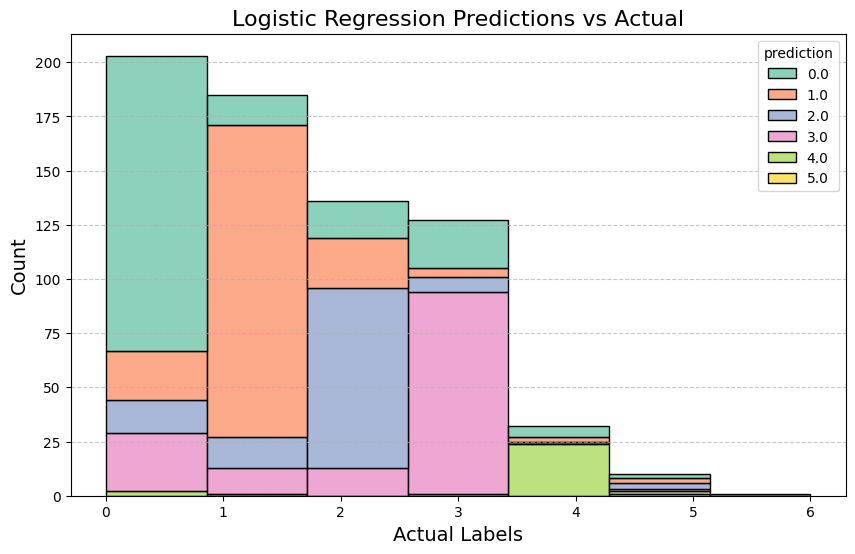

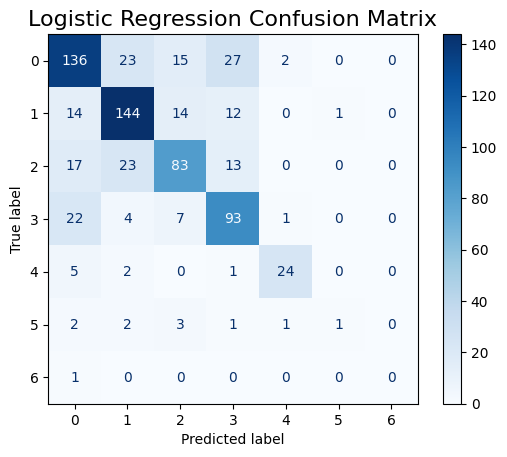

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=lr_predictions_pd,
    x="label",
    hue="prediction",
    multiple="stack",
    bins=len(lr_predictions_pd["label"].unique()),
    palette="Set2"
)
plt.title("Logistic Regression Predictions vs Actual", fontsize=16)
plt.xlabel("Actual Labels", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.7)

handles, labels = plt.gca().get_legend_handles_labels()
if handles:
    plt.legend(handles=handles, labels=labels, title="Predicted Labels", loc='upper right')

plt.show()

cm_lr = confusion_matrix(lr_predictions_pd["label"], lr_predictions_pd["prediction"])
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp_lr.plot(cmap="Blues", values_format="d")
plt.title("Logistic Regression Confusion Matrix", fontsize=16)
plt.show()

#### MLP

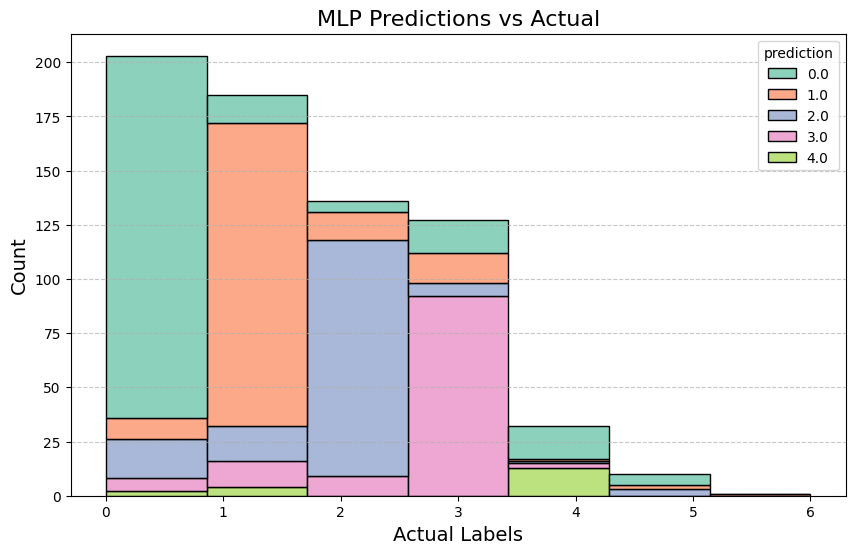

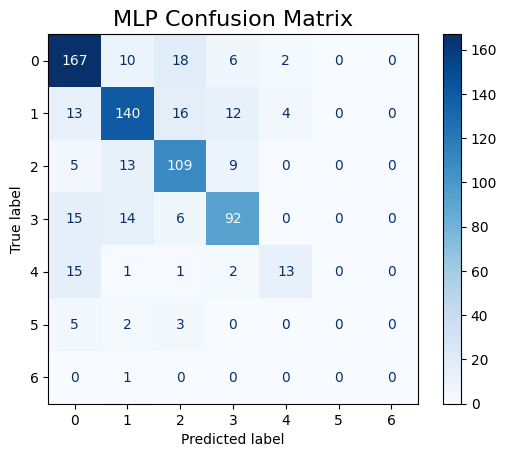

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=mlp_predictions_pd,
    x="label",
    hue="prediction",
    multiple="stack",
    bins=len(mlp_predictions_pd["label"].unique()),
    palette="Set2"
)
plt.title("MLP Predictions vs Actual", fontsize=16)
plt.xlabel("Actual Labels", fontsize=14)
plt.ylabel("Count", fontsize=14)

handles, labels = plt.gca().get_legend_handles_labels()
if handles:
    plt.legend(handles=handles, labels=labels, title="Predicted Labels", loc='upper right')

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

cm_mlp = confusion_matrix(mlp_predictions_pd["label"], mlp_predictions_pd["prediction"])
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp)
disp_mlp.plot(cmap="Blues", values_format="d")
plt.title("MLP Confusion Matrix", fontsize=16)
plt.show()

#### XGBoost

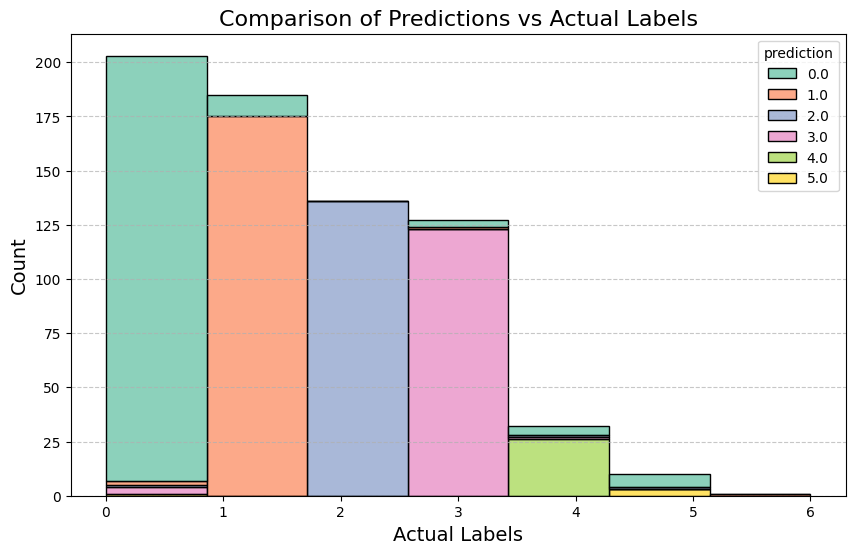

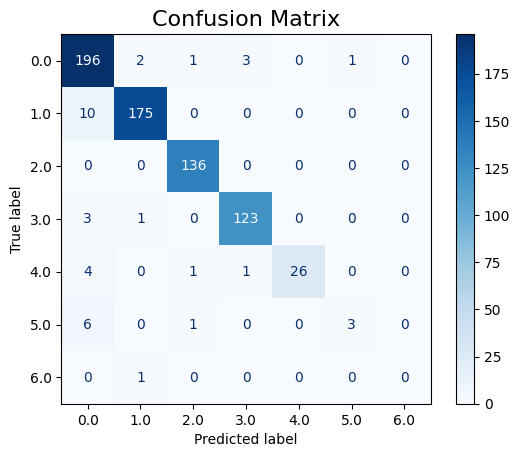

In [ ]:
actual_labels = pandas_predictions['label']
predicted_labels = pandas_predictions['prediction']

unique_labels = sorted(pandas_predictions['label'].unique())
plt.figure(figsize=(10, 6))

sns.histplot(
    data=pandas_predictions,
    x='label',
    hue='prediction',
    multiple='stack',
    bins=len(unique_labels),
    palette='Set2',
    kde=False
)

plt.title('Comparison of Predictions vs Actual Labels', fontsize=16)
plt.xlabel('Actual Labels', fontsize=14)
plt.ylabel('Count', fontsize=14)

handles, labels = plt.gca().get_legend_handles_labels()
if handles:
    plt.legend(handles=handles, labels=labels, title="Predicted Labels", loc='upper right')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

conf_matrix = confusion_matrix(actual_labels, predicted_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=sorted(actual_labels.unique()))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix', fontsize=16)
plt.show()